# Movement-premium calibration audit

This artifact-only Plan 7 audit asks why the predictable online movement premium is much larger than its population counterpart. It loads completed Plan 6-8 artifacts without training a learner, estimating a Fisher matrix, or changing any historical result.

## Estimands and substitutions

For the deployed batch size $m=4$, Plan 8 estimates

$$
\widehat\rho_t=\frac{m\widehat S_t}{\widehat D_t},\qquad
\widehat\pi_t^{\mathrm{inst}}=\frac{\widehat S_t+q_t\widehat D_t}{\widehat S_t+q_t\widehat D_t+\widehat D_t/m}.
$$

The population one-step Fisher-risk recommendation is

$$
\pi_{B,t}^{\mathrm{marg}}=\frac{S_t+q_tD_t^{\mathrm{old}}}{S_t+q_tD_t^{\mathrm{old}}+D_t^{\mathrm{new}}/m}.
$$

The audit preserves each realized pre-transition $q_t$ and substitutes either population $S_t$ or population $(D_t^{\mathrm{old}},D_t^{\mathrm{new}})$ while holding the other online coefficient fixed. These are coefficient-attribution counterfactuals, not alternative learner trajectories or path-optimal policies.

In [8]:
from pathlib import Path
import sys

REPO_ROOT = next(
    candidate
    for candidate in (Path.cwd(), *Path.cwd().parents)
    if (candidate / 'mnist_experiment' / 'plan7.md').is_file()
)
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from mnist_experiment.rotated_mnist.phase7_movement_artifacts import (
    load_completed_movement_premium_audit,
)

RUN_ID = 'rotated_mnist_phase7_movement_audit_primary_v2__replica-0001__c24262eac6ec1625'
RUN_PATH = (
    REPO_ROOT / 'cache/mnist_experiment/rotated_mnist/phase7/'
    'movement_premium_audit' / RUN_ID
)
audit = load_completed_movement_premium_audit(RUN_PATH)
rows = pd.DataFrame(audit.movement_rows)
summary = pd.DataFrame(audit.audit_summary['summaries'])
breakdowns = audit.audit_summary['error_breakdowns']
print(f'Loaded {len(rows)} transitions from {audit.config.run_id}')
print(audit.audit_summary['evidence_classification'])

Loaded 400 transitions from rotated_mnist_phase7_movement_audit_primary_v2__replica-0001__c24262eac6ec1625
{'attribution_tolerance': 0.01, 'primary': 'numerator_dominated', 'single_trajectory_feasibility': 'structurally_underidentified', 'smoothing_conclusion': 'does_not_remove_level_bias', 'trend_interpretation': 'consistent_with_estimand_mismatch'}


## Attribution result

Replacing only the online movement numerator $\widehat S_t$ with population $S_t$ nearly reproduces the all-population action. Replacing only the covariance scale does not: it exposes an even larger recommendation because the inflated online denominator had partially masked the numerator error.

In [9]:
table = summary[[
    'design', 'schedule', 'eligible_transition_count',
    'mean_applied_pi', 'mean_online_instantaneous_pi',
    'mean_covariance_only_pi', 'mean_population_marginal_pi',
    'median_signal_ratio', 'median_scale_ratio',
    'applied_pi_mae', 'online_instantaneous_pi_mae',
    'population_signal_online_scale_pi_mae',
    'online_signal_population_scale_pi_mae',
]].copy()
table.columns = [
    'Design', 'Schedule', 'n', 'Applied pi', 'Online instantaneous pi',
    'Tracked-q covariance pi', 'Population marginal pi',
    'Median S-hat / S', 'Median D-hat / D-new',
    'Applied MAE', 'Online instantaneous MAE',
    'Population S + online D MAE', 'Online S + population D MAE',
]
display(table.round(4).style.hide(axis='index'))

Design,Schedule,n,Applied pi,Online instantaneous pi,Tracked-q covariance pi,Population marginal pi,Median S-hat / S,Median D-hat / D-new,Applied MAE,Online instantaneous MAE,Population S + online D MAE,Online S + population D MAE
double_lap,linear,112,0.291600,0.235500,0.147500,0.150100,969.815500,123.413500,0.141400,0.085400,0.002800,0.685000
double_lap,sigmoid,112,0.122600,0.123100,0.059400,0.062500,299.374400,25.719700,0.060100,0.060600,0.003100,0.540800
single_lap,linear,72,0.170600,0.176900,0.080800,0.083500,1276.297300,62.536200,0.087100,0.093400,0.002800,0.773400
single_lap,sigmoid,72,0.144800,0.166200,0.066400,0.069200,1092.130500,61.231500,0.076400,0.097300,0.003000,0.728300


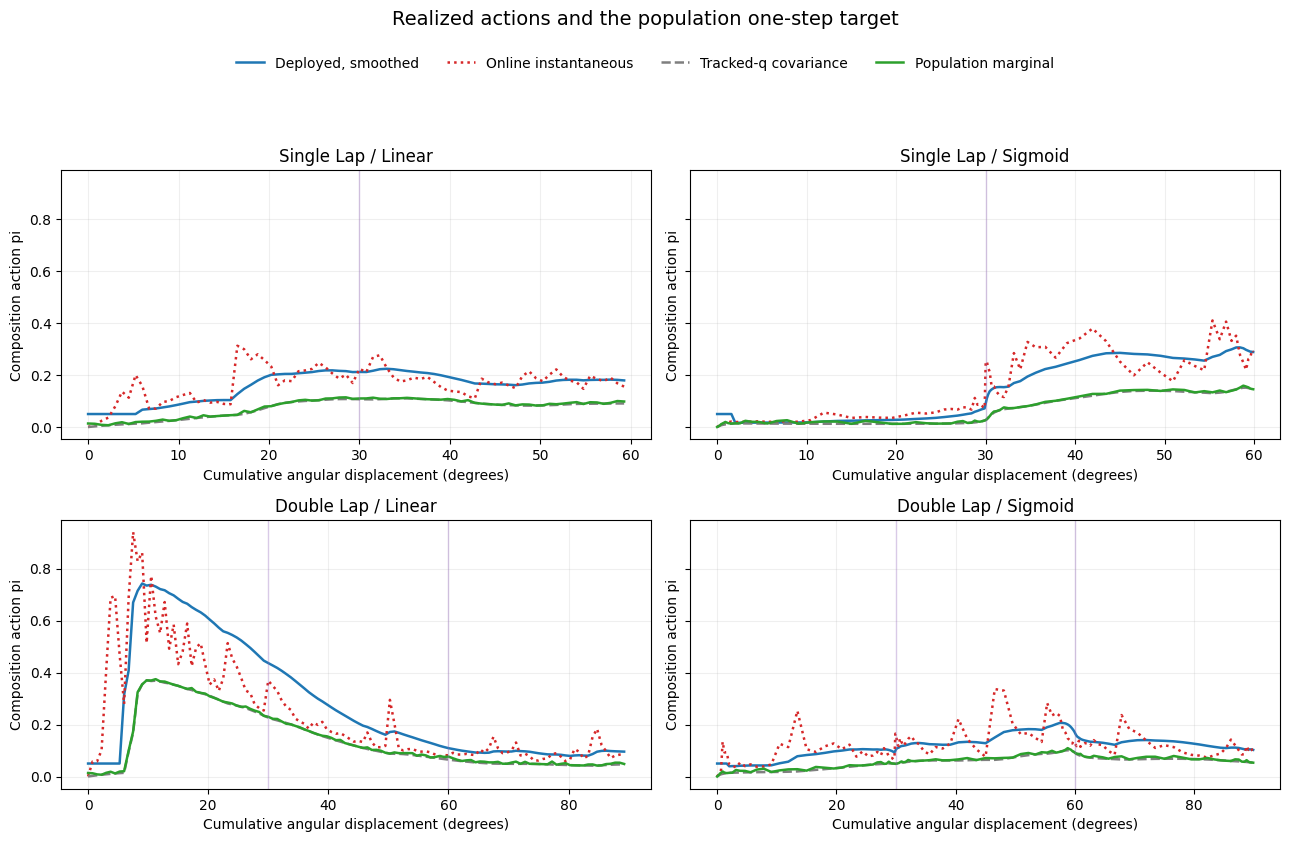

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8.5), sharey=True)
designs = ('single_lap', 'double_lap')
schedules = ('linear', 'sigmoid')
styles = {
    'applied_pi': ('#1f77b4', '-', 'Deployed, smoothed'),
    'online_instantaneous_pi': ('#d62728', ':', 'Online instantaneous'),
    'tracked_q_covariance_pi': ('#7f7f7f', '--', 'Tracked-q covariance'),
    'population_marginal_pi': ('#2ca02c', '-', 'Population marginal'),
}
for row_index, design in enumerate(designs):
    for column_index, schedule in enumerate(schedules):
        ax = axes[row_index, column_index]
        selected = rows[(rows.design == design) & (rows.schedule == schedule)]
        for name, (color, line, label) in styles.items():
            ax.plot(
                selected.cumulative_angular_degrees, selected[name],
                color=color, linestyle=line, linewidth=1.8, label=label,
            )
        for step in selected.loc[selected.reversal_window & (selected.steps_since_reversal == 0), 'cumulative_angular_degrees']:
            ax.axvline(step, color='#9467bd', alpha=.35, linewidth=1)
        ax.set_title(f"{design.replace('_', ' ').title()} / {schedule.title()}")
        ax.set_xlabel('Cumulative angular displacement (degrees)')
        ax.set_ylabel('Composition action pi')
        ax.grid(alpha=.2)
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.suptitle('Realized actions and the population one-step target', y=.985, fontsize=14)
fig.legend(
    handles, labels, loc='upper center', bbox_to_anchor=(.5, .945),
    ncol=4, frameon=False,
)
fig.tight_layout(rect=(0, 0, 1, .88))
plt.show()

The tracked-$q_t$ covariance component remains near the population marginal recommendation. The movement term raises both instantaneous and deployed actions substantially. Smoothing changes timing, especially after direction reversals, but does not remove the level error.

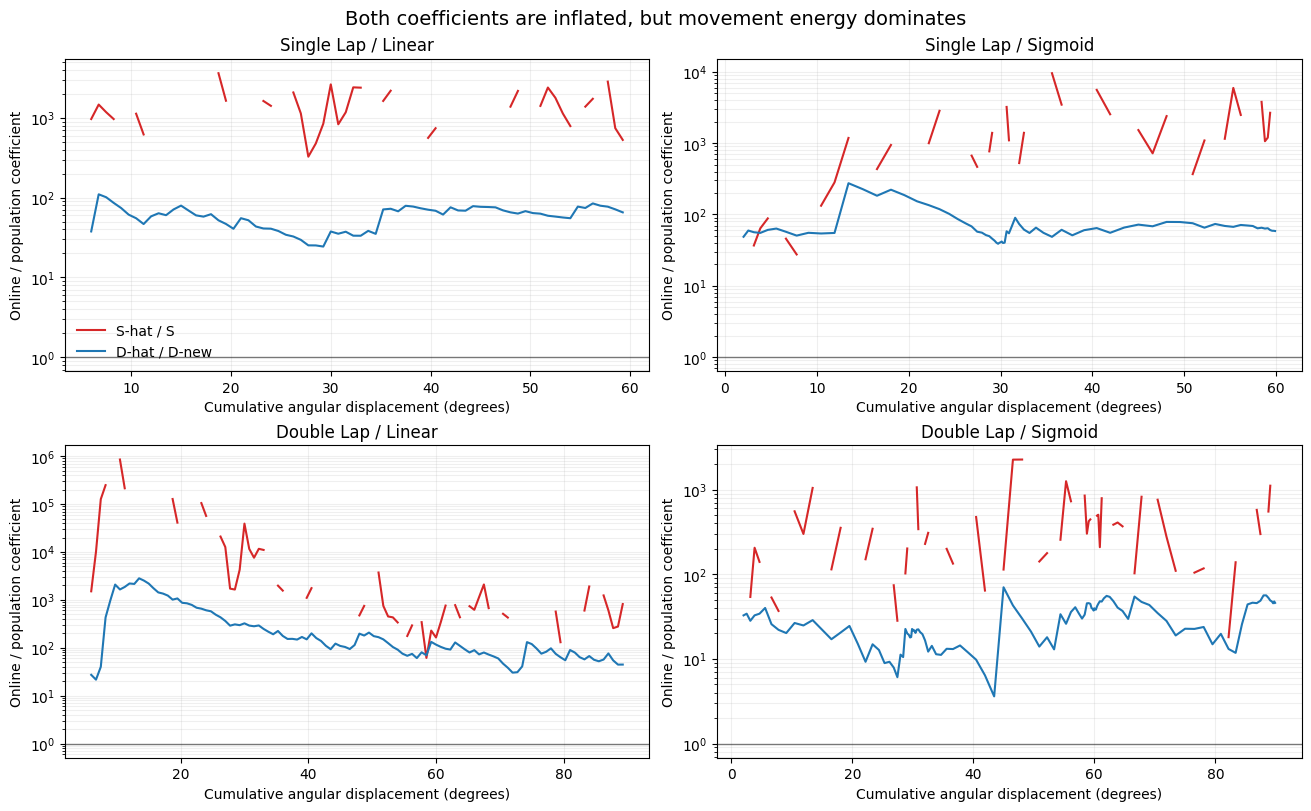

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8), constrained_layout=True)
for row_index, design in enumerate(designs):
    for column_index, schedule in enumerate(schedules):
        ax = axes[row_index, column_index]
        selected = rows[(rows.design == design) & (rows.schedule == schedule) & rows.eligible]
        ax.plot(
            selected.cumulative_angular_degrees,
            selected.online_signal / selected.population_signal,
            color='#d62728', linewidth=1.5, label='S-hat / S',
        )
        ax.plot(
            selected.cumulative_angular_degrees,
            selected.online_scale / selected.population_new_scale,
            color='#1f77b4', linewidth=1.5, label='D-hat / D-new',
        )
        ax.axhline(1.0, color='black', linewidth=1, alpha=.5)
        ax.set_yscale('log')
        ax.set_title(f"{design.replace('_', ' ').title()} / {schedule.title()}")
        ax.set_xlabel('Cumulative angular displacement (degrees)')
        ax.set_ylabel('Online / population coefficient')
        ax.grid(alpha=.2, which='both')
axes[0, 0].legend(frameon=False)
fig.suptitle('Both coefficients are inflated, but movement energy dominates', fontsize=14)
plt.show()

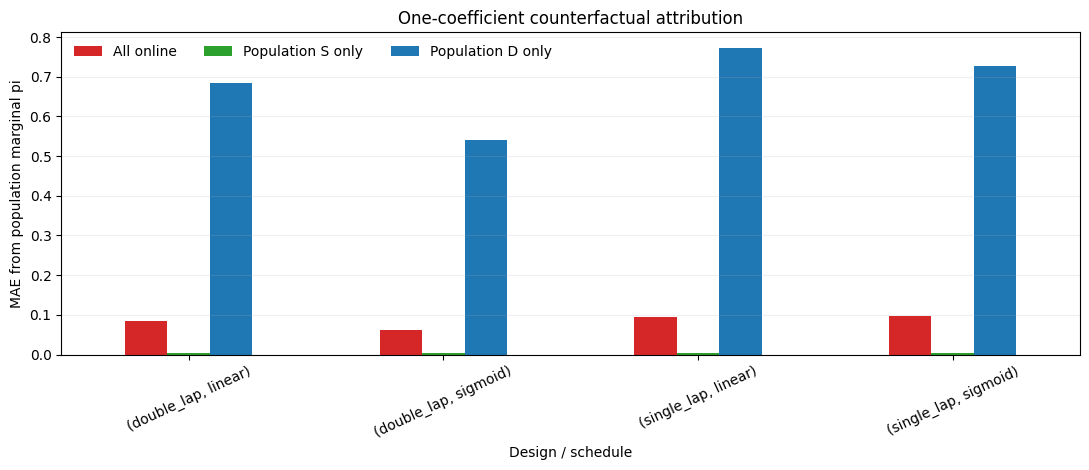

In [12]:
errors = summary.set_index(['design', 'schedule'])[[
    'online_instantaneous_pi_mae',
    'population_signal_online_scale_pi_mae',
    'online_signal_population_scale_pi_mae',
]].rename(columns={
    'online_instantaneous_pi_mae': 'All online',
    'population_signal_online_scale_pi_mae': 'Population S only',
    'online_signal_population_scale_pi_mae': 'Population D only',
})
ax = errors.plot.bar(figsize=(11, 4.8), color=['#d62728', '#2ca02c', '#1f77b4'])
ax.set_ylabel('MAE from population marginal pi')
ax.set_xlabel('Design / schedule')
ax.set_title('One-coefficient counterfactual attribution')
ax.tick_params(axis='x', rotation=25)
ax.grid(axis='y', alpha=.2)
ax.legend(frameon=False, ncol=3)
plt.tight_layout()
plt.show()

## Reversal and smoothing check

The double-lap paths provide two direction reversals. The table reports the first eight transitions after each reversal. Positive signed error means the recommendation exceeds the population one-step target.

In [13]:
reversals = pd.DataFrame(breakdowns['reversal_windows'])
if reversals.empty:
    print('No reversal windows were present.')
else:
    display(reversals.round(4).style.hide(axis='index'))

applied_pi_mae,applied_pi_signed_error,design,eligible_transition_count,mean_smoothing_shift,online_instantaneous_pi_mae,online_instantaneous_pi_signed_error,reversal_step,schedule,window_steps
0.188900,0.188900,double_lap,8,0.110700,0.078200,0.078200,40,linear,8
0.035500,0.035500,double_lap,8,0.011700,0.023800,0.023800,80,linear,8
0.060000,0.060000,double_lap,8,-0.020500,0.080500,0.080500,40,sigmoid,8
0.065800,0.065800,double_lap,8,0.027400,0.038400,0.038400,80,sigmoid,8
0.107500,0.107500,single_lap,8,-0.001400,0.109000,0.109000,40,linear,8
0.086600,0.086600,single_lap,8,-0.056000,0.142700,0.142700,40,sigmoid,8


## Interpretation

1. **The Plan 7 covariance correction holds.** Reusing each path's endogenous $q_t$ puts the covariance-only action close to the population marginal action before movement is added.
2. **The discrepancy is numerator-dominated.** Across all four design/schedule groups, replacing $\widehat S_t$ alone reduces action MAE below `.0032`; replacing the covariance scale alone makes it much worse.
3. **The online denominator is also inflated.** Its inflation partly masks, rather than causes, the much larger movement-energy inflation.
4. **Smoothing cannot repair the estimand.** It can reduce variance, but the deployed action retains systematic level error and carries history across reversals.
5. **A single low-data trajectory is insufficient to recover population movement without another assumption.** The observed trend includes realized-anchor catch-up, optimizer motion, temporal curvature, and sampling variation. The quadratic identity $\mathbb E\|\widehat d_t\|_{\mathcal I_t}^2=\|\mathbb E\widehat d_t\|_{\mathcal I_t}^2+\operatorname{tr}(\mathcal I_t\operatorname{Cov}(\widehat d_t))$ shows why variance can inflate it, but this audit cannot identify that variance separately from a non-population trend mean.

The result diagnoses estimation of the instantaneous movement premium only. It neither establishes path-optimality nor rules out movement-aware control supplied with repeated local probes or stronger state assumptions.

In [14]:
checks = pd.Series(audit.audit_summary['operational_diagnostics'], name='Value')
display(checks.to_frame())
display(pd.Series(audit.source_contract['run_ids'], name='Immutable source run'))

,Value
all_finite,True
all_transitions_matched,True
maximum_action_reconstruction_error,0.0
maximum_plugin_reconstruction_error,0.0
maximum_population_coefficient_reproduction_error,0.0
maximum_q_reconstruction_error,0.0
reused_population_transition_count,240
row_count,400
unique_population_transition_count,160


coefficient    rotated_mnist_phase7_anchor_audit_primary_v3__...
double_lap     rotated_mnist_phase8_double_lap_reversal_stres...
oracle         rotated_mnist_phase6_oracle_full_path__replica...
single_lap     rotated_mnist_phase8_single_lap_rechallenge__r...
Name: Immutable source run, dtype: object